## Data visualization

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.data_load import load_nuclear_data

df = load_nuclear_data("../data/raw/nuclear_safety.xlsx")
df['station'] = df['station'].replace('ЮУАЕС', 'ПАЕС')

In [52]:
df_plot = df.copy()

cols_to_drop = ['year', 'quarter', 'iodine_ radionuclides_index']

cols_to_drop = [c for c in cols_to_drop if c in df_plot.columns]

df_plot = df_plot.drop(columns=cols_to_drop)

print("Columns used for plotting:")
print(df_plot.columns)

numeric_cols = df_plot.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

Columns used for plotting:
Index(['station', 'irg', 'irg_index', 'iodine_ radionuclides',
       'stable_radionuclides', 'stable_ radionuclides_index',
       'cs_137_emission', 'co_60_ emission', 'cs_137_dump', 'co_60_dump',
       'volume', 'index_radioactive_releas', 'index_dump'],
      dtype='object')
Numeric columns:
['irg', 'irg_index', 'iodine_ radionuclides', 'stable_radionuclides', 'stable_ radionuclides_index', 'cs_137_emission', 'co_60_ emission', 'cs_137_dump', 'co_60_dump', 'volume', 'index_radioactive_releas', 'index_dump']


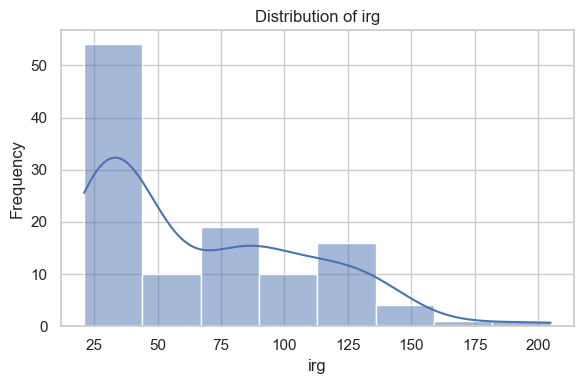

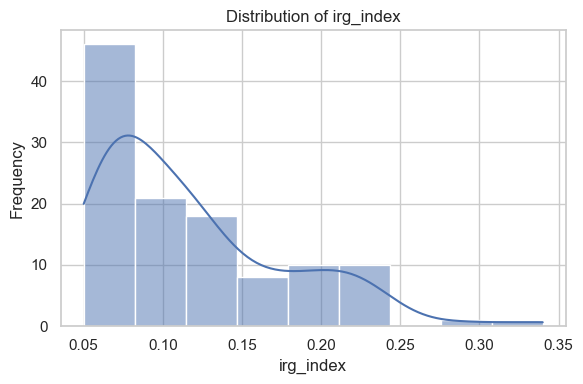

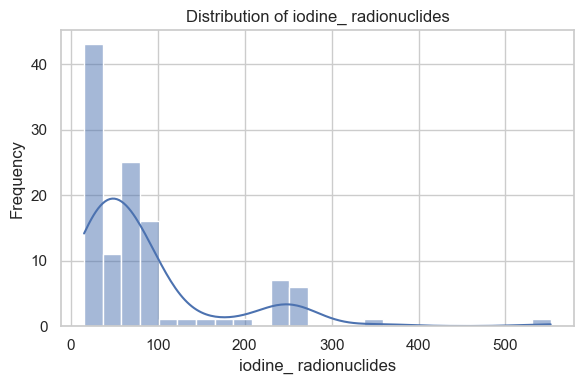

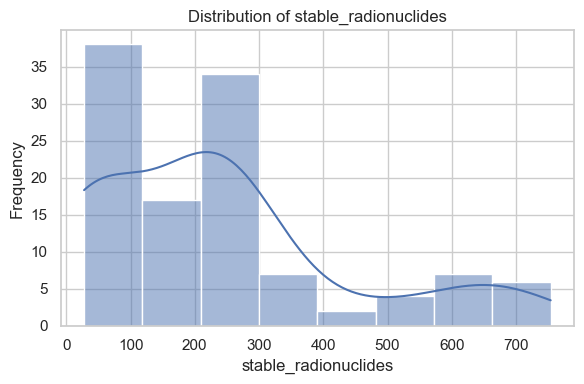

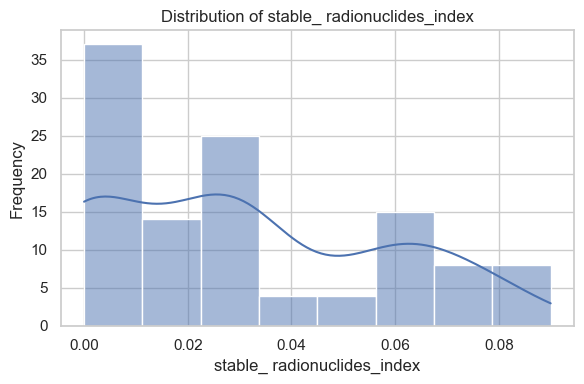

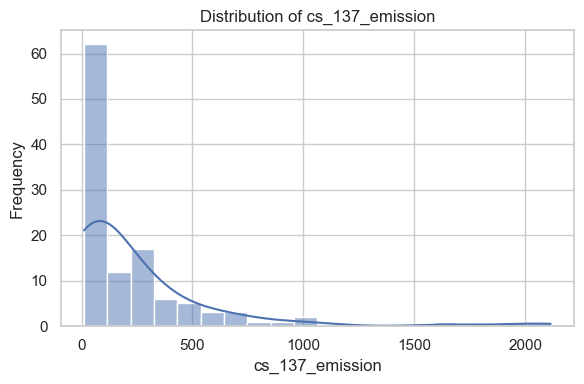

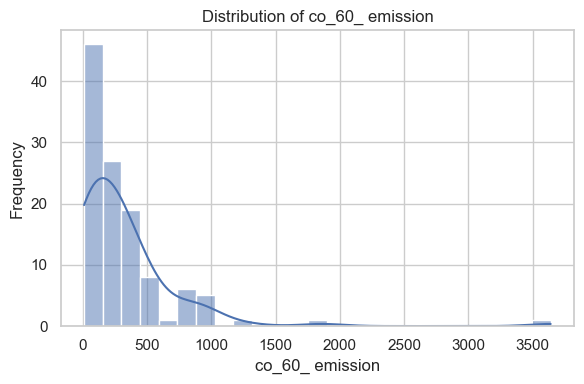

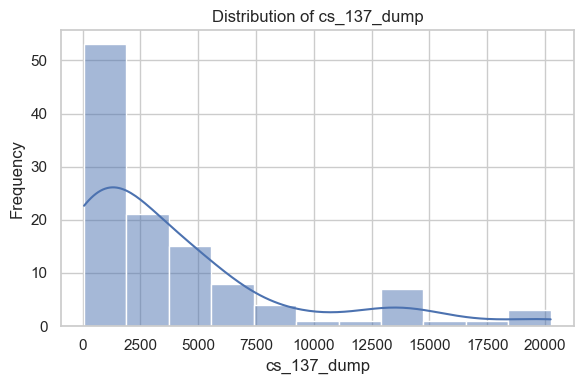

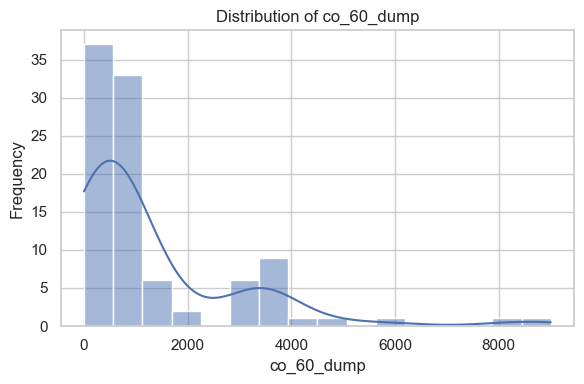

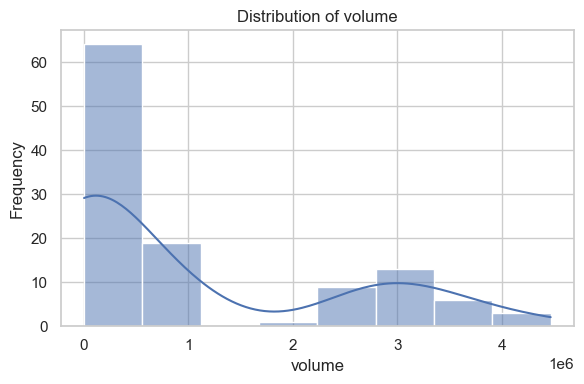

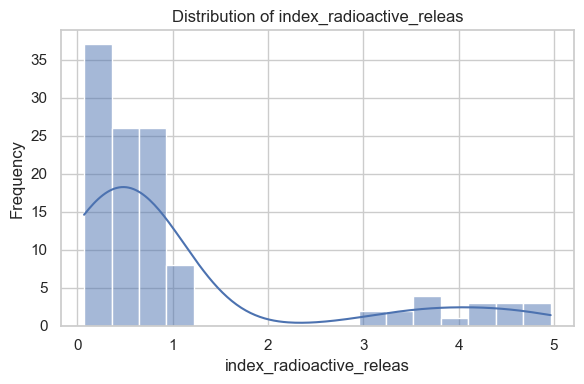

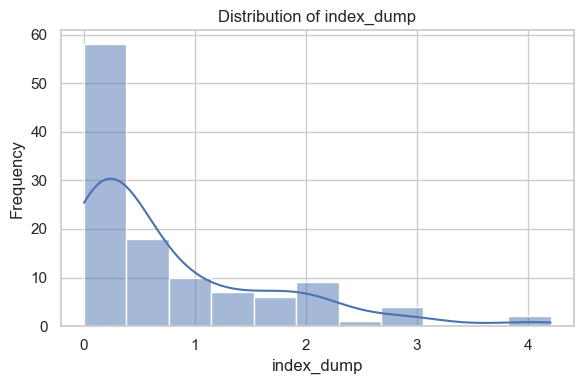

In [53]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_plot[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

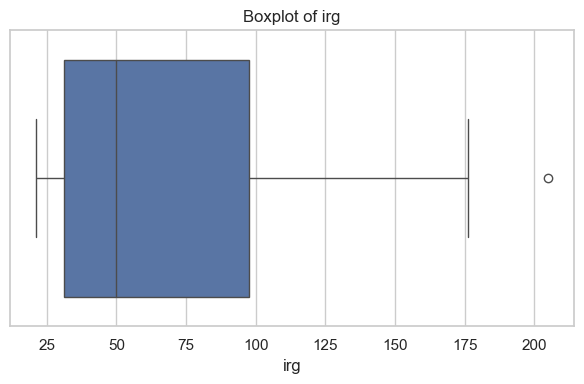

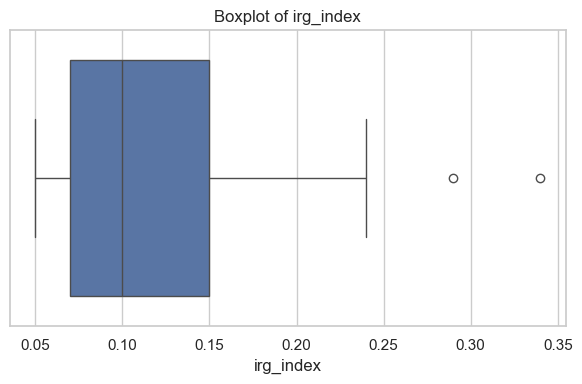

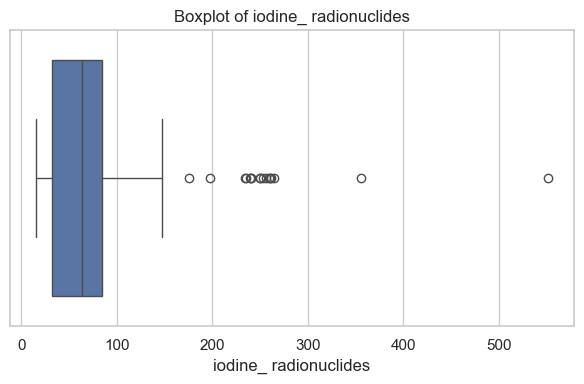

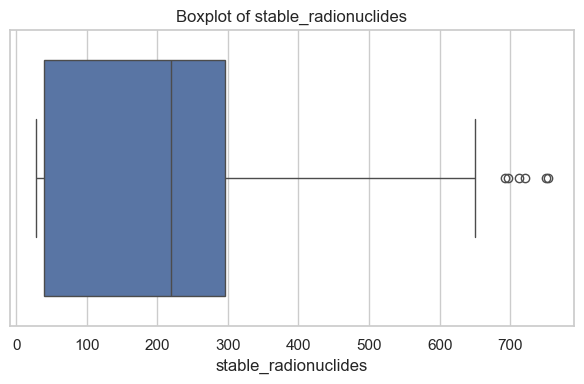

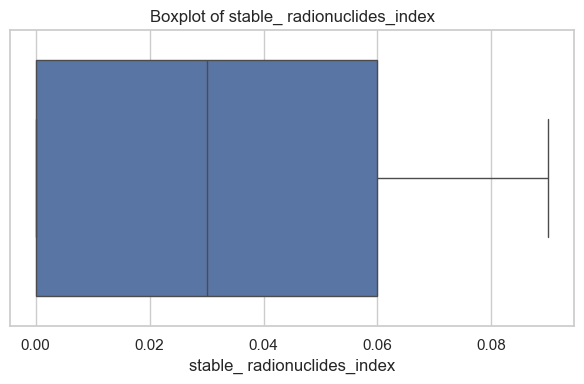

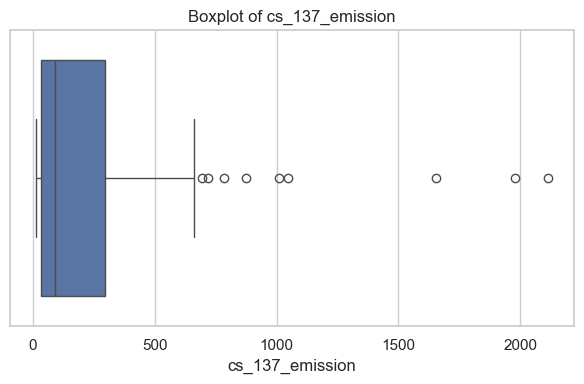

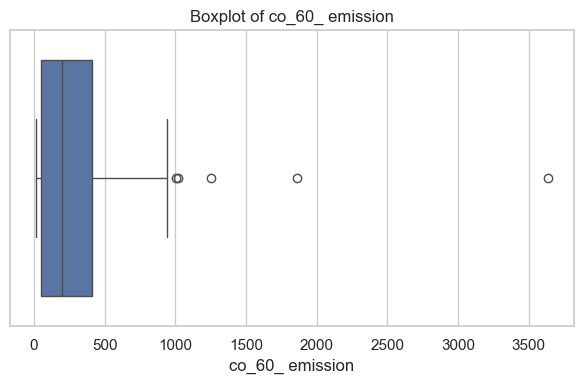

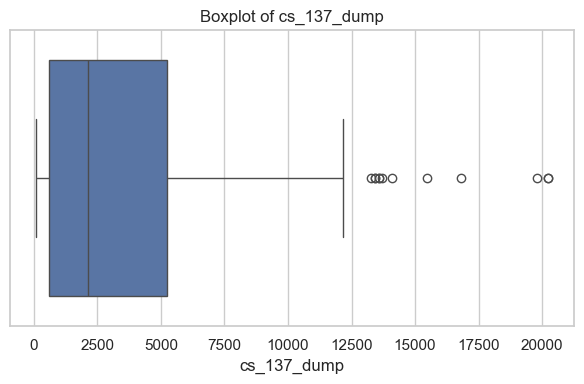

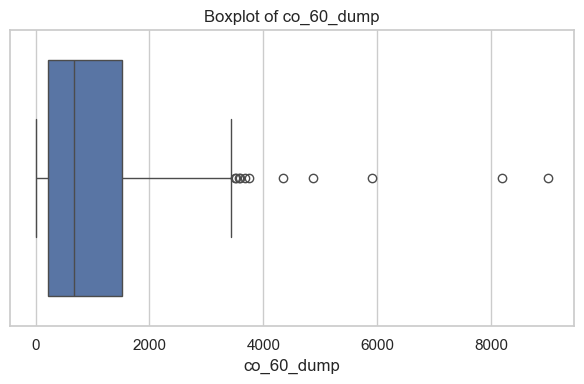

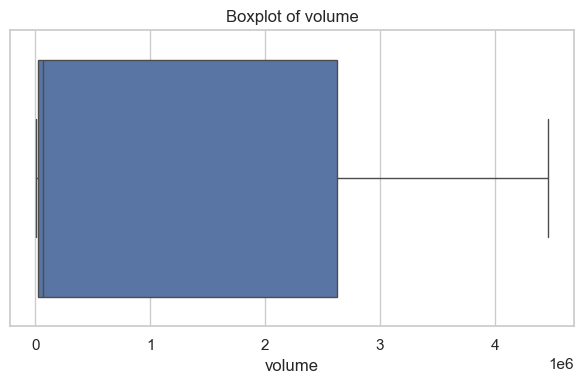

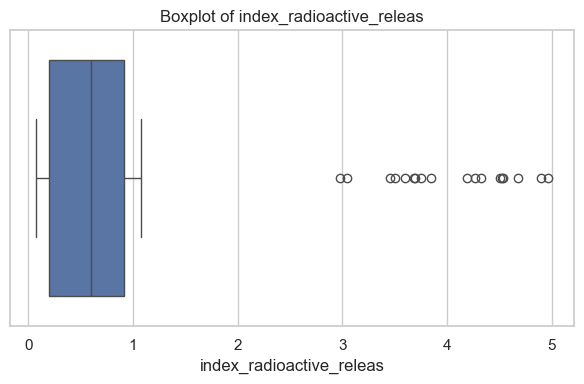

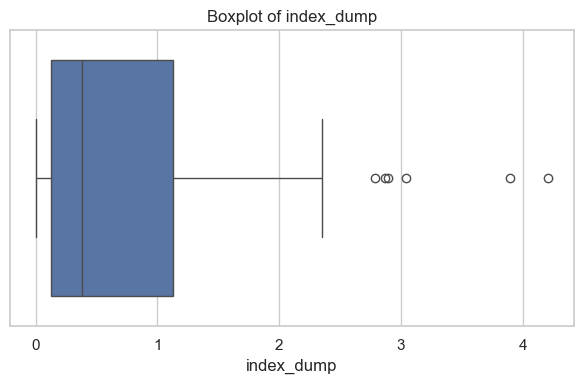

In [36]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_plot[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

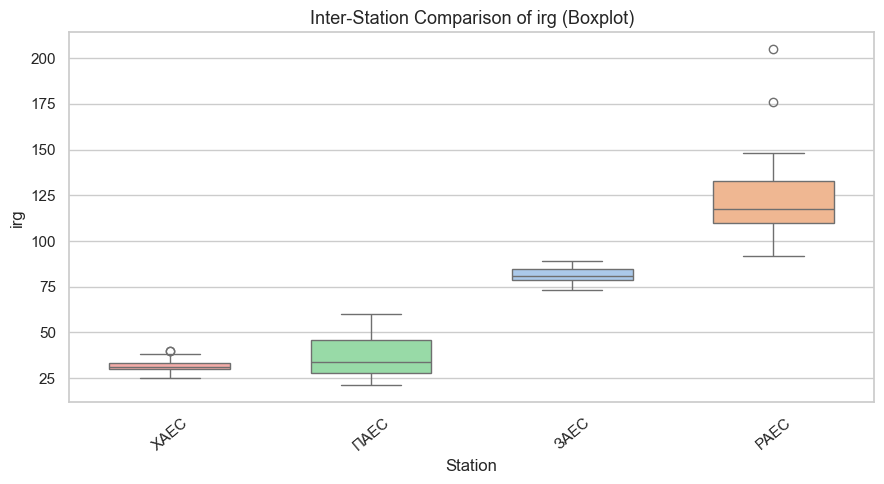

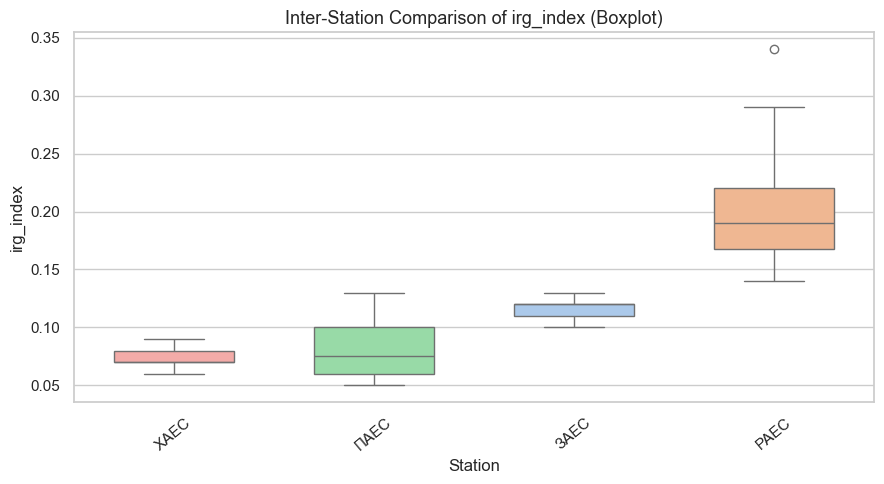

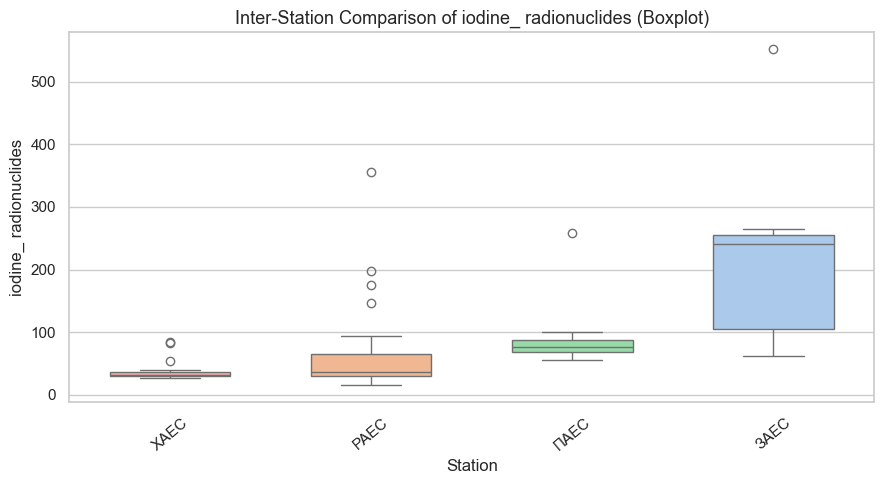

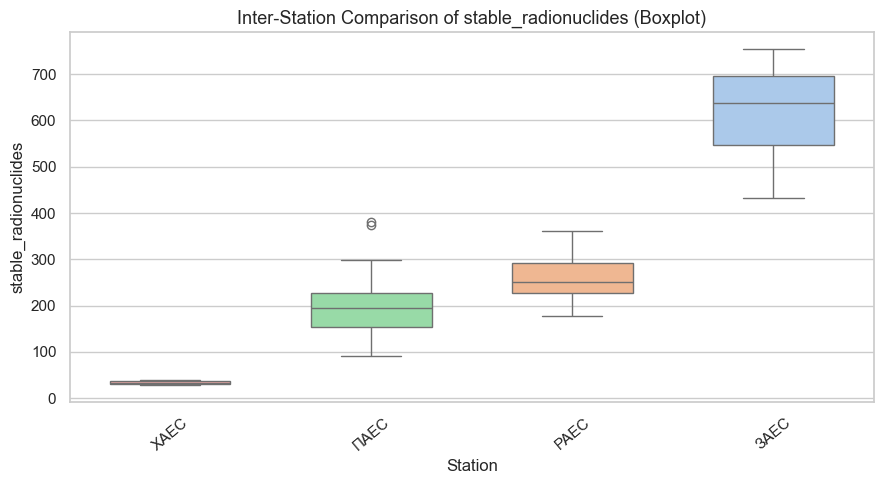

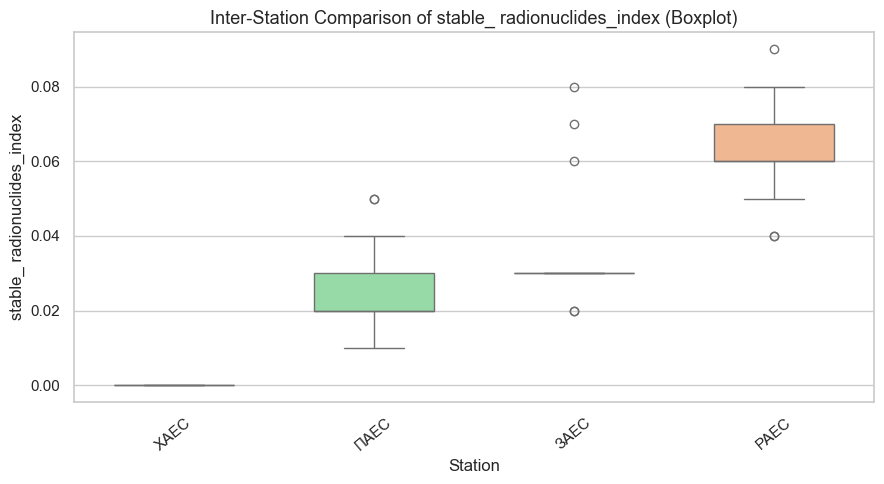

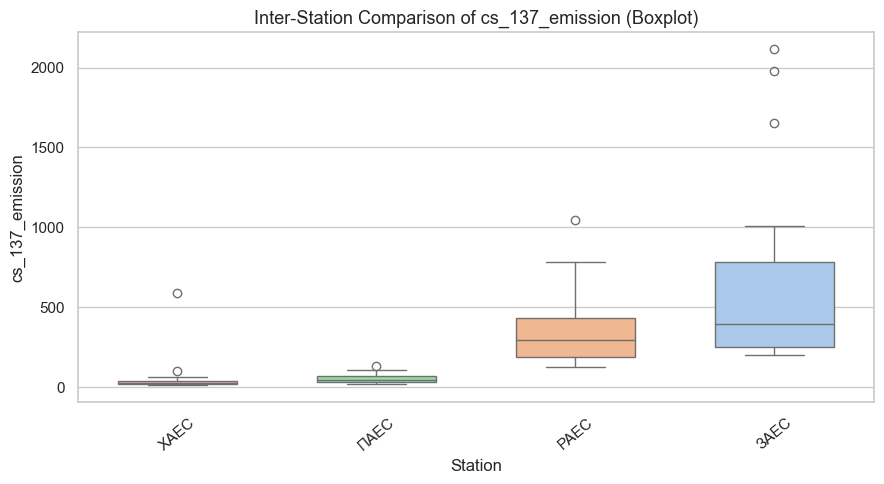

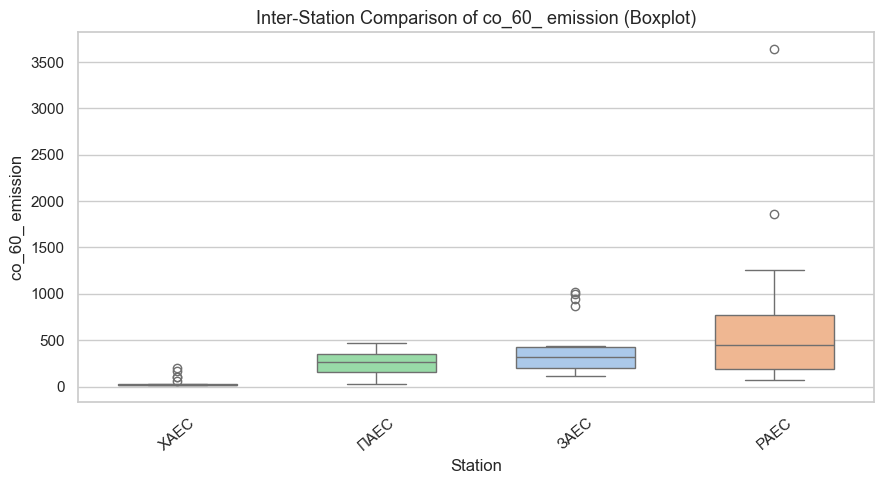

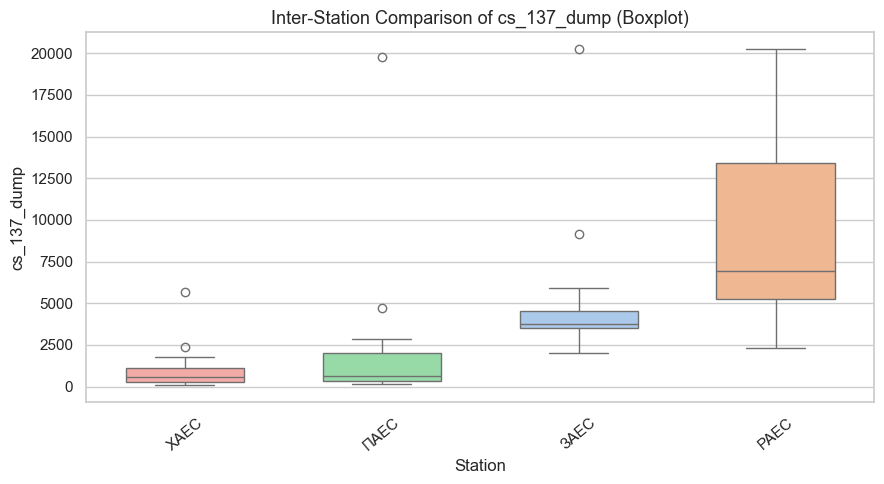

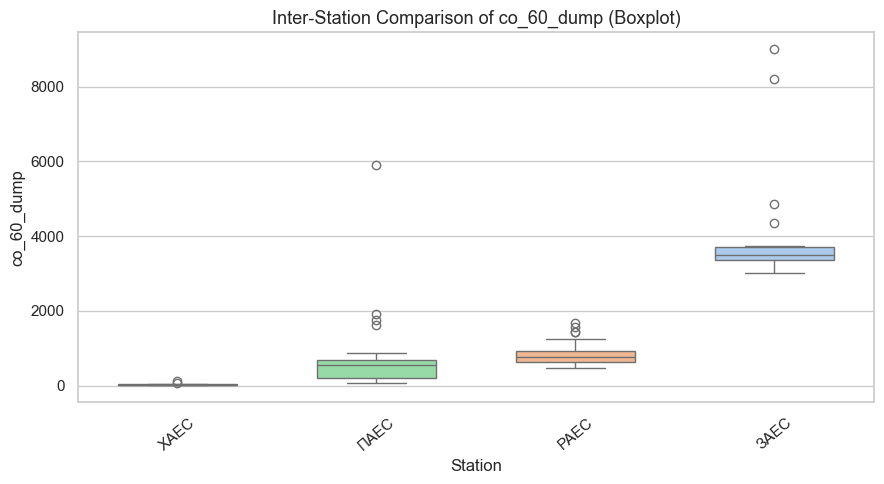

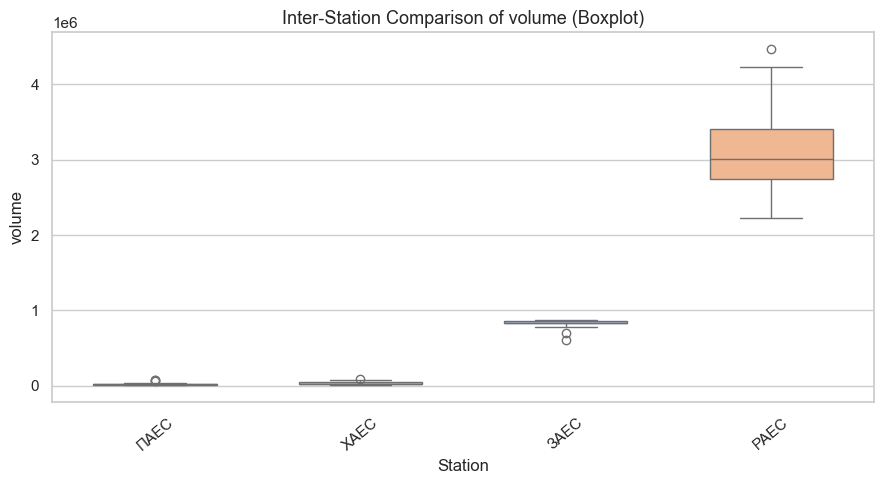

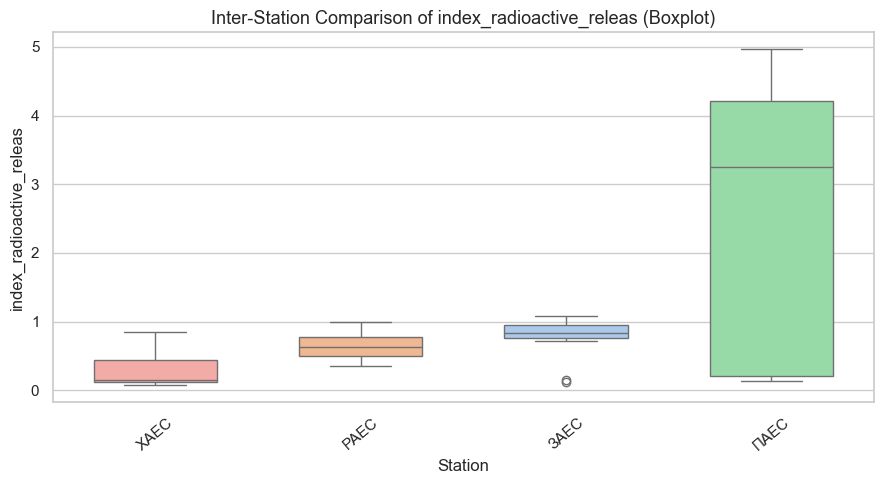

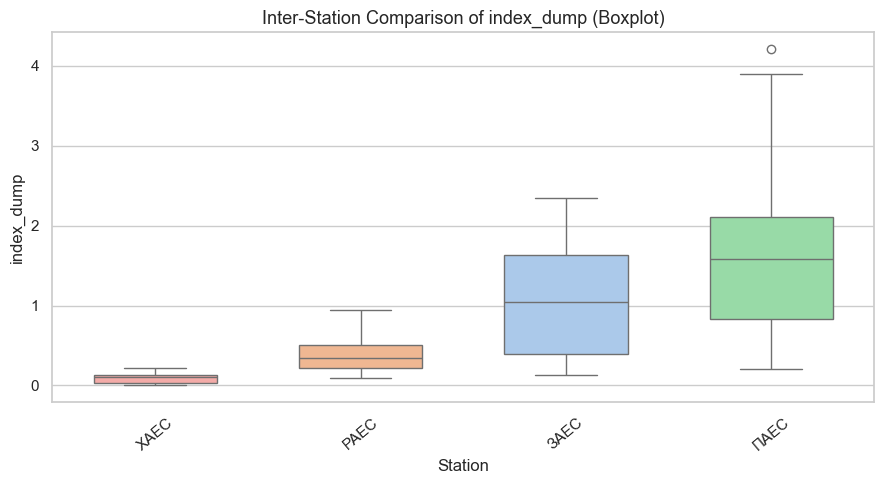

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

if 'station' in df_plot.columns:
    for col in numeric_cols:
        plt.figure(figsize=(9,5))
        order = (
            df_plot.groupby("station")[col]
            .median()
            .sort_values()
            .index
        )
        
        sns.boxplot(
            data=df_plot,
            x='station',
            y=col,
            order=order,
            hue='station',
            palette="pastel",
            width=0.6
        )
        
        plt.title(f"Inter-Station Comparison of {col} (Boxplot)", fontsize=13)
        plt.xlabel("Station")
        plt.ylabel(col)
        plt.xticks(rotation=40)
        plt.tight_layout()
        plt.show()

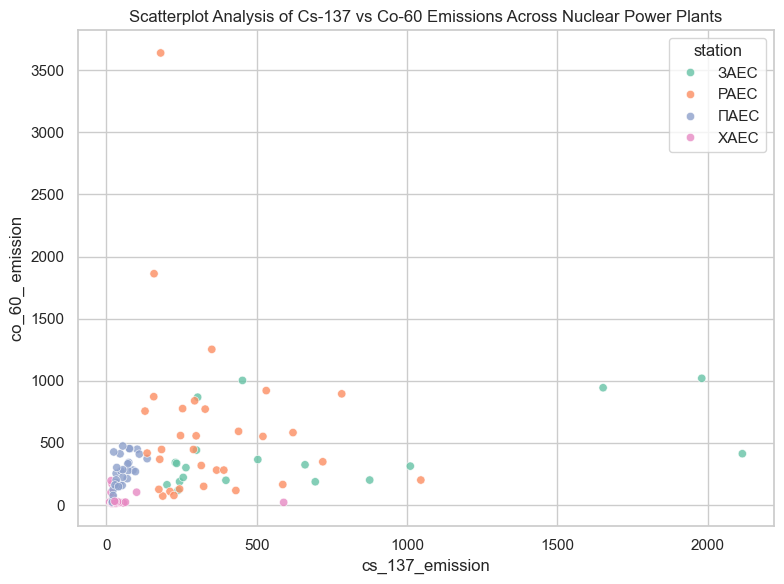

In [55]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_plot, x='cs_137_emission', y='co_60_ emission', hue='station', palette='Set2', alpha=0.8)
plt.title("Scatterplot Analysis of Cs-137 vs Co-60 Emissions Across Nuclear Power Plants")
plt.tight_layout()
plt.show()

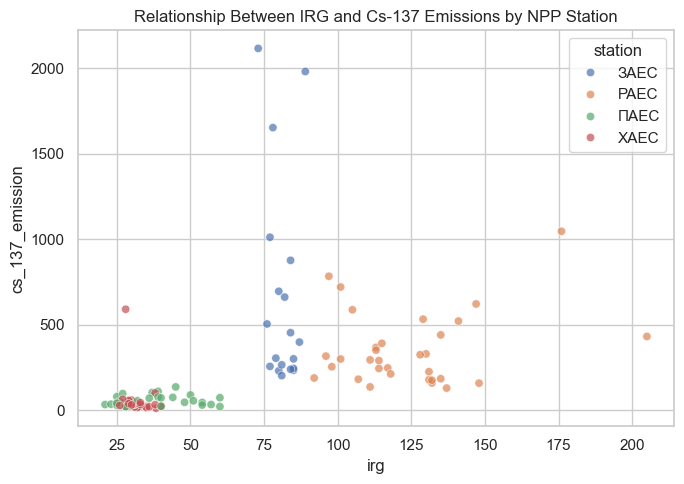

In [56]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_plot, x='irg', y='cs_137_emission', hue='station', alpha=0.7)
plt.title("Relationship Between IRG and Cs-137 Emissions by NPP Station")
plt.tight_layout()
plt.show()

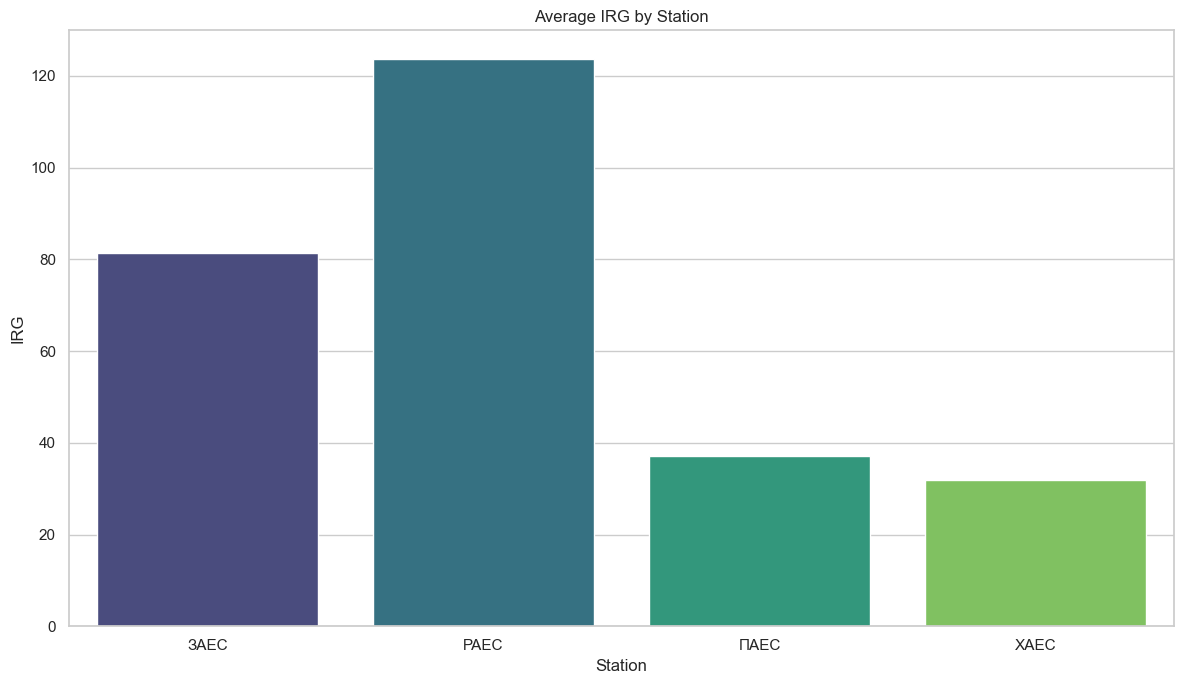

In [47]:
plt.figure()
sns.barplot(data=df, x='station', hue='station', y='irg', palette='viridis', errorbar=None)
plt.title("Average IRG by Station")
plt.xlabel("Station")
plt.ylabel("IRG")
plt.tight_layout()
plt.savefig('../reports/figures/average_irg.png')
plt.show()


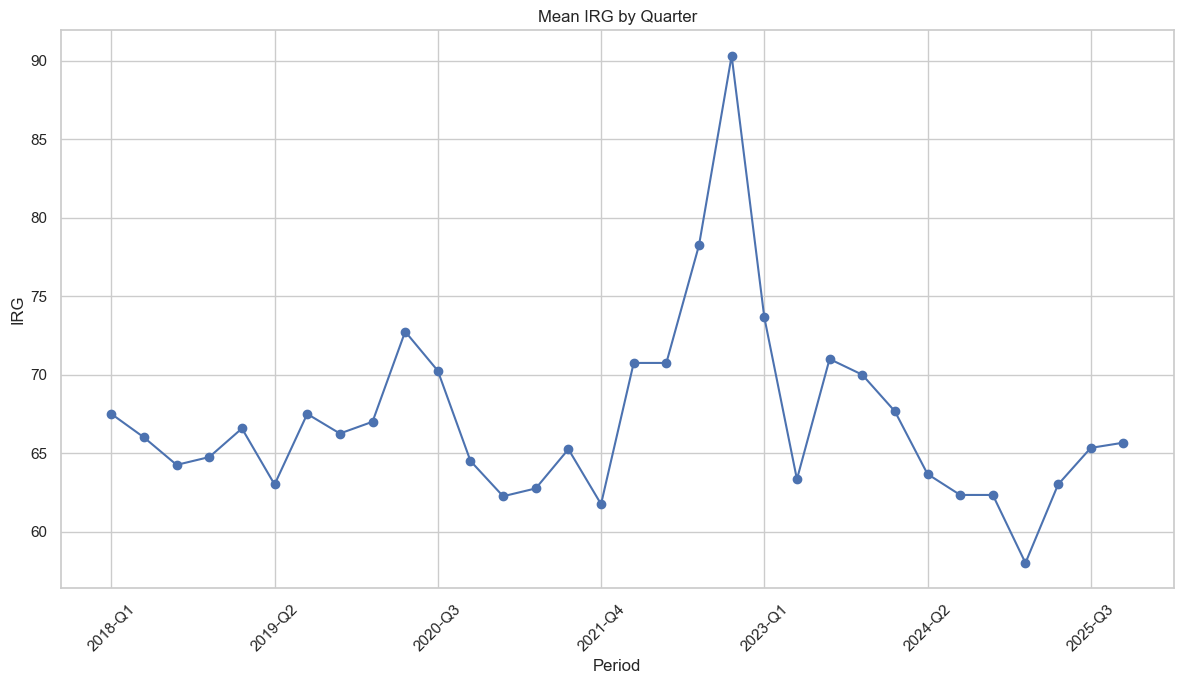

<Figure size 1200x700 with 0 Axes>

In [48]:
df["period"] = df["year"].astype(str) + "-Q" + df["quarter"].astype(str)
plt.figure()
df.groupby("period")["irg"].mean().plot(marker="o")
plt.title("Mean IRG by Quarter")
plt.xlabel("Period")
plt.ylabel("IRG")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('../reports/figures/irg_trend.png')